In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import mysql.connector
db=mysql.connector.connect

# 1. Connect to your MySQL Workbench Database
db = mysql.connector.connect(
    host="localhost",
    user="root",           # Your MySQL username
    password="Rohan@123", # Your MySQL password
    database="supply_chain" # The name of your database
)

print("Connected successfully ✅")

# create cursor
cursor = db.cursor()

# run query
cursor.execute("SHOW DATABASES")

# print output
for i in cursor:
    print(i)


Connected successfully ✅
('db',)
('home_practise',)
('information_schema',)
('learn_join',)
('mydatabase',)
('mysql',)
('performance_schema',)
('practice',)
('salesdb',)
('sql_practice',)
('supply_chain',)
('sys',)


In [3]:
# SQL query
query = """
select distinct p.ProductName,s.ContactName from supplier s 
join product p on s.Id=p.SupplierId
join orderitem oi on p.id=oi.productid
where oi.UnitPrice>100;
"""
df = pd.read_sql(query, db)

print(df)

               ProductName     ContactName
0  Thüringer Rostbratwurst     Martin Bein
1            Côte de Blaye  Guylène Nodier


C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\3335220222.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\1808897927.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query1, db)


   total_order  Year_in
0          408     2013
1          270     2014
2          152     2012


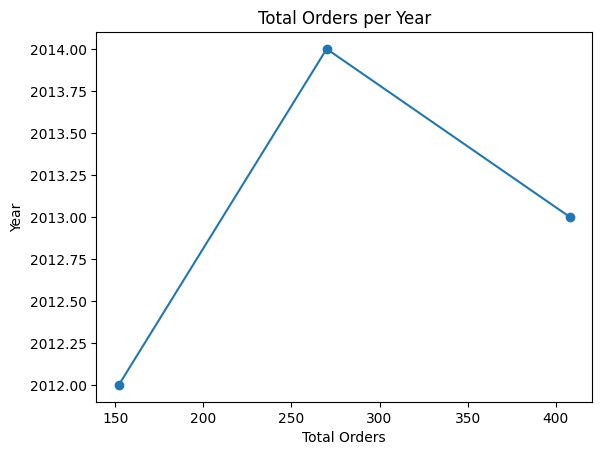

In [7]:
### 12. Display the total number of orders delivered every year

query1="""select count(id) as total_order,year(orderdate) as Year_in from orders
group by year(orderdate)
order by total_order desc;"""

# load data
df = pd.read_sql(query1, db)
# ensure Year_in is integer type, not float
df['Year_in'] = df['Year_in'].astype(int)
print(df)

plt.figure()
plt.plot(df['total_order'], df['Year_in'], marker='o')


plt.title("Total Orders per Year")
plt.ylabel("Year")
plt.xlabel("Total Orders")

plt.show()

C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\2194086923.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,db)


Text(0.5, 0, 'country')

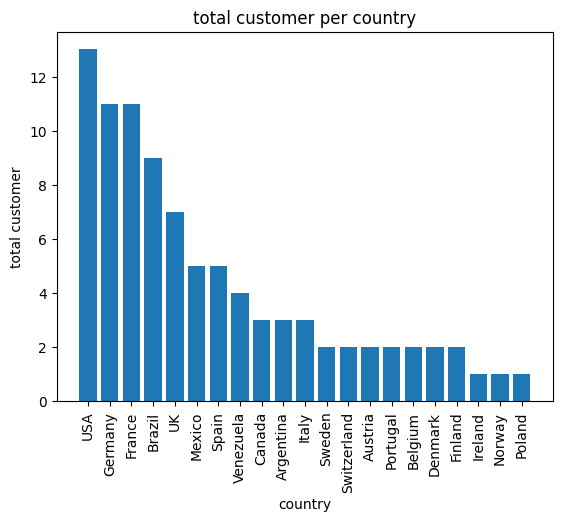

In [5]:
query="""select country , count(id) as total_customer from  customer
group by country 
order by total_customer desc ;"""

df=pd.read_sql(query,db)
df

plt.Figure()
plt.xticks(rotation=90)
plt.bar(df["country"],df["total_customer"])
plt.title("total customer per country")
plt.ylabel("total customer")
plt.xlabel("country")

C:\Users\Rohan Srivastav\AppData\Local\Temp\ipykernel_9624\3393204307.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


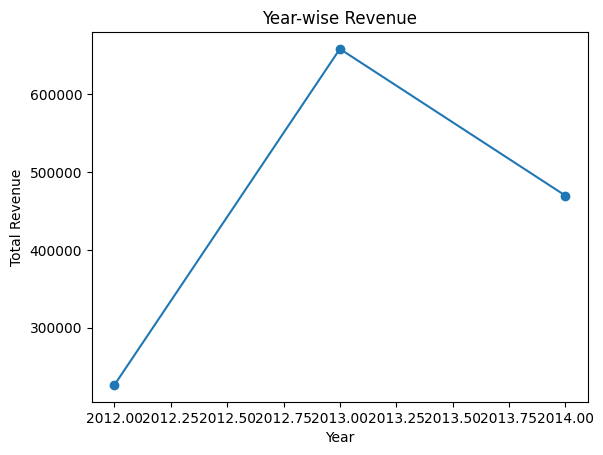

In [ ]:
#1. 💰 Year-wise Revenue
query="""SELECT YEAR(orderdate) AS year, 
       SUM(totalamount) AS total_revenue 
FROM orders 
GROUP BY YEAR(orderdate)
ORDER BY year;"""

df = pd.read_sql(query, db)
# ensure year is integer type for plotting and display
df['year'] = df['year'].astype(int)
plt.figure()
plt.plot(df['year'], df['total_revenue'], marker='o')
plt.title("Year-wise Revenue")  
plt.xlabel("Year")
plt.ylabel("Total Revenue ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()